In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import os
import cv2
from PIL import Image
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D , MaxPool2D , Flatten , Dropout , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from keras.callbacks import ReduceLROnPlateau



In [6]:
dataset_path = "chest_xray"
labels = ['PNEUMONIA', 'NORMAL']
img_size = 150


In [ ]:
def build_dataframe(base_path):
    data = []
    for split in ['train', 'test', 'val']:
        split_path = os.path.join(base_path, split)
        for label in labels:
            label_path = os.path.join(split_path, label)
            for filename in os.listdir(label_path):
                file_path = os.path.join(label_path, filename)
                try:
                    # Read image in grayscale (like original code)
                    img_arr = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
                    resized_arr = cv2.resize(img_arr, (img_size, img_size))

                    # Also get metadata using PIL
                    with Image.open(file_path) as img:
                        img_type = 'RGB' if img.mode == 'RGB' else 'Grayscale'
                        width, height = img.size

                    data.append({
                        'split': split,
                        'label': label,
                        'class_num': labels.index(label),
                        'filename': filename,
                        'path': file_path,
                        'extension': os.path.splitext(filename)[1].lower(),
                        "image_type": img_type,
                        "width": width,
                        "height": height,
                        "array": resized_arr   # numpy array of resized image

                    })
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")
                    data.append({
                        'split': split,
                        'label': label,
                        'class_num': labels.index(label),
                        'filename': filename,
                        'path': file_path,
                        'extension': os.path.splitext(filename)[1].lower(),
                        'image_type': 'Unreadable',
                        'width': None,
                        'height': None,
                        'array': None
                    })

    df = pd.DataFrame(data)
    return df




In [8]:

df = build_dataframe(dataset_path)


In [9]:
# Split into separate DataFrames
train_df = df[df['split'] == 'train'].reset_index(drop=True)
test_df = df[df['split'] == 'test'].reset_index(drop=True)
val_df = df[df['split'] == 'val'].reset_index(drop=True)


In [10]:
print(df["split"].unique())
print(df["label"].value_counts())


['train' 'test' 'val']
label
PNEUMONIA    4273
NORMAL       1583
Name: count, dtype: int64


<Axes: xlabel='label', ylabel='count'>

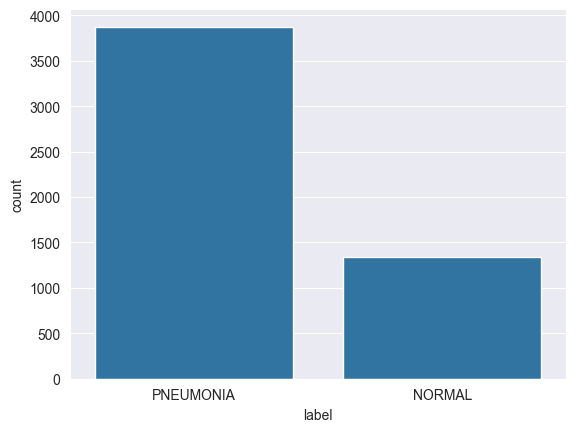

In [11]:
# Countplot
sns.set_style('darkgrid')
sns.countplot(x="label", data=train_df)


Text(0.5, 1.0, 'NORMAL')

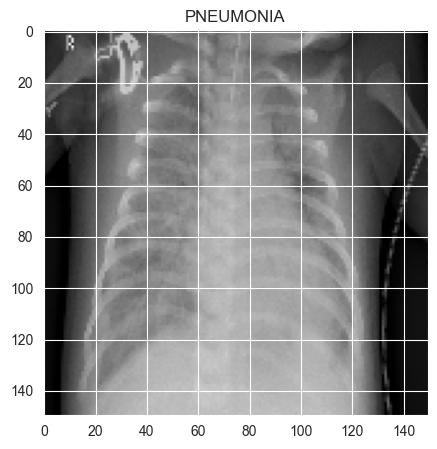

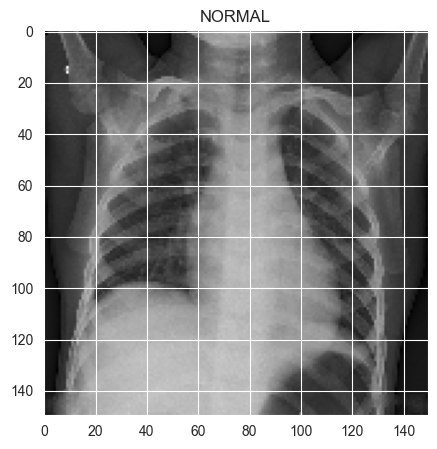

In [12]:
# Show sample images
plt.figure(figsize=(5,5))
plt.imshow(train_df.iloc[0]['array'], cmap='gray')
plt.title(train_df.iloc[0]['label'])

plt.figure(figsize=(5,5))
plt.imshow(train_df.iloc[-1]['array'], cmap='gray')
plt.title(train_df.iloc[-1]['label'])



In [13]:
# Prepare arrays for training
x_train = np.array(list(train_df['array'])) / 255.0
y_train = np.array(list(train_df['class_num']))

x_val = np.array(list(val_df['array'])) / 255.0
y_val = np.array(list(val_df['class_num']))

x_test = np.array(list(test_df['array'])) / 255.0
y_test = np.array(list(test_df['class_num']))



In [14]:

# Reshape for CNN input
x_train = x_train.reshape(-1, img_size, img_size, 1)
x_val = x_val.reshape(-1, img_size, img_size, 1)
x_test = x_test.reshape(-1, img_size, img_size, 1)


In [15]:

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=False
)

datagen.fit(x_train)


In [16]:
model = Sequential()
model.add(Conv2D(32 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu' , input_shape = (150,150,1)))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(64 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.1))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(64 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(128 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(256 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Flatten())
model.add(Dense(units = 128 , activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(units = 1 , activation = 'sigmoid'))
model.compile(optimizer = "rmsprop" , loss = 'binary_crossentropy' , metrics = ['accuracy'])
model.summary()

c:\Users\tooba\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,246,401 (4.75 MB)

 Trainable params: 1,245,313 (4.75 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [17]:
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy', 
    patience = 2, 
    verbose=1,
    factor=0.3, 
    min_lr=0.000001)

In [18]:
history = model.fit(datagen.flow(x_train,y_train, batch_size = 32) ,
                    epochs = 12 , 
                    validation_data = datagen.flow(x_val, y_val) ,
                    callbacks = [learning_rate_reduction])

c:\Users\tooba\anaconda3\envs\tf_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.8024 - loss: 1.0645 - val_accuracy: 0.5000 - val_loss: 34.4209 - learning_rate: 0.0010
Epoch 2/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.8947 - loss: 0.2718 - val_accuracy: 0.5000 - val_loss: 26.3775 - learning_rate: 0.0010
Epoch 3/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 856ms/step - accuracy: 0.9201 - loss: 0.2116
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
163/163 ━━━━━━━━━━━━━━━━━━━━ 140s 857ms/step - accuracy: 0.9201 - loss: 0.2117 - val_accuracy: 0.5000 - val_loss: 24.4981 - learning_rate: 0.0010
Epoch 4/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 121s 743ms/step - accuracy: 0.9383 - loss: 0.1579 - val_accuracy: 0.7500 - val_loss: 0.4455 - learning_rate: 3.0000e-04
Epoch 5/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 122s 751ms/step - accuracy: 0.9598 - loss: 0.1196 - val_accuracy: 0.6875 - val_loss: 1.0827 - learning_rate: 3.0000e-04
Epoch 6/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 788ms/step - accura

In [19]:
loss, acc = model.evaluate(x_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", acc*100, "%")


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.9408 - loss: 0.1919
Test Loss: 0.21918396651744843
Test Accuracy: 91.82692170143127 %


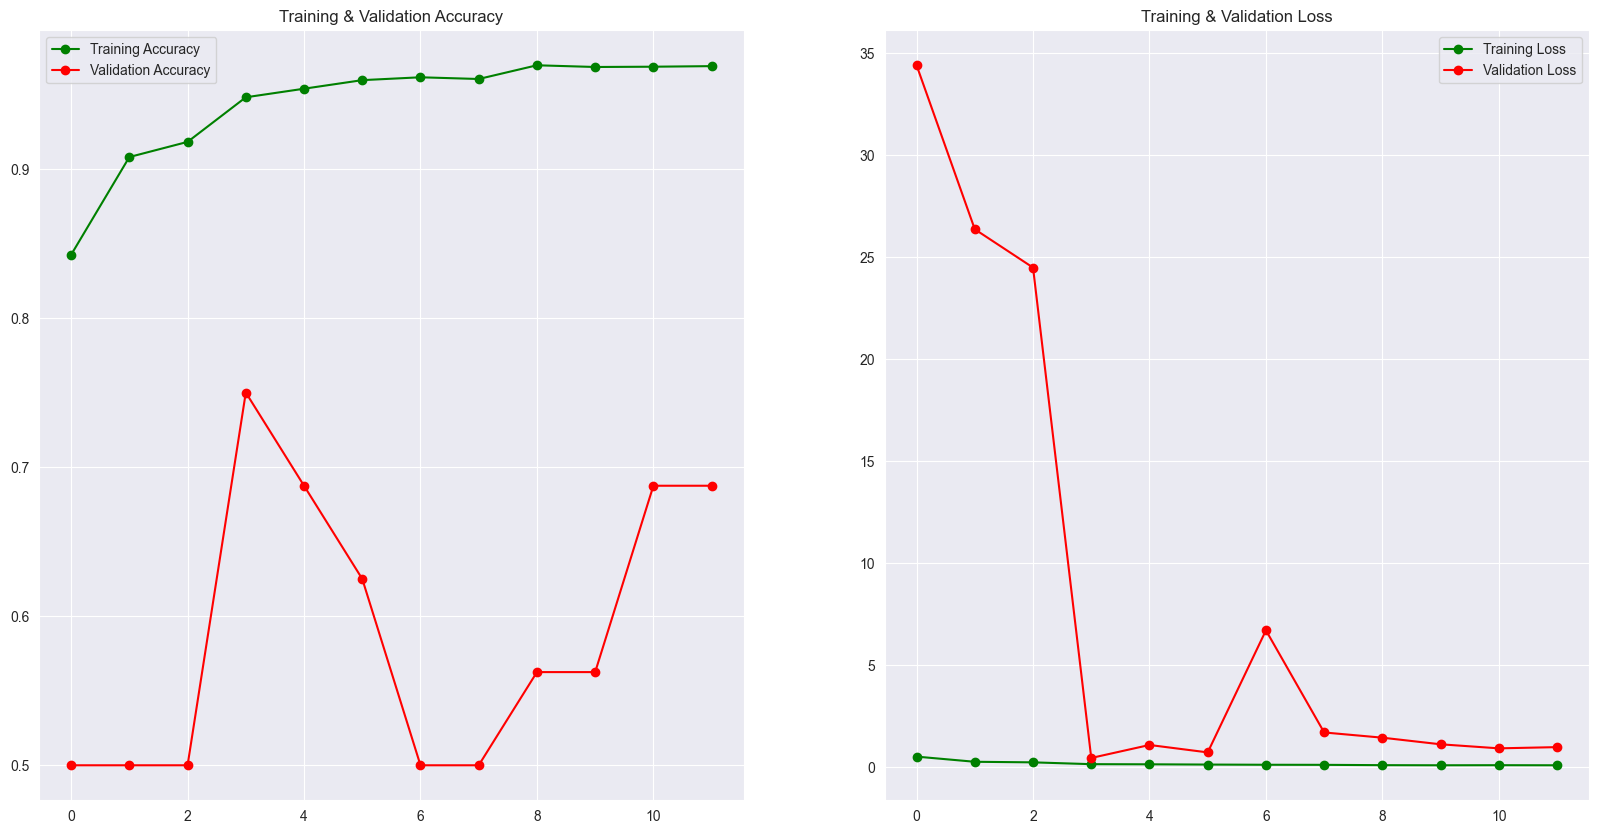

In [20]:
epochs = range(12)
fig, ax = plt.subplots(1,2, figsize=(20,10))

ax[0].plot(epochs, history.history['accuracy'], 'go-', label='Training Accuracy')
ax[0].plot(epochs, history.history['val_accuracy'], 'ro-', label='Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()

ax[1].plot(epochs, history.history['loss'], 'g-o', label='Training Loss')
ax[1].plot(epochs, history.history['val_loss'], 'r-o', label='Validation Loss')
ax[1].set_title('Training & Validation Loss')
ax[1].legend()

plt.show()


In [21]:
predictions = (model.predict(x_test) > 0.5).astype("int32").reshape(-1)
print(classification_report(y_test, predictions, target_names=['Pneumonia (Class 0)','Normal (Class 1)']))




20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step
                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.92      0.95      0.94       390
   Normal (Class 1)       0.91      0.87      0.89       234

           accuracy                           0.92       624
          macro avg       0.92      0.91      0.91       624
       weighted avg       0.92      0.92      0.92       624



In [22]:
cm = confusion_matrix(y_test, predictions)
cm_df = pd.DataFrame(cm, index=['0','1'], columns=['0','1'])

<Axes: >

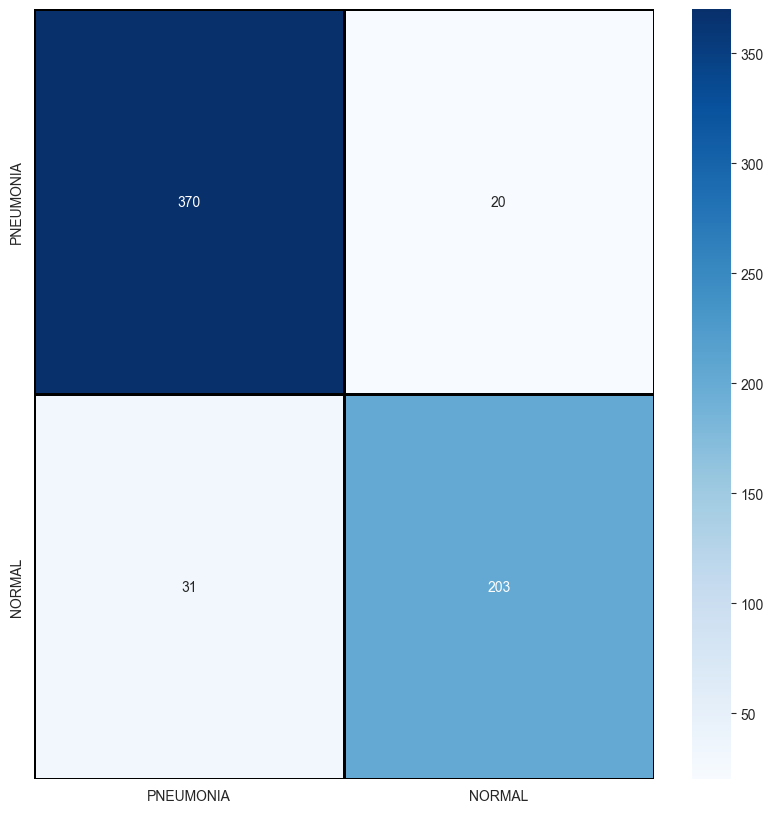

In [23]:
plt.figure(figsize=(10,10))
sns.heatmap(cm_df, cmap="Blues", linecolor='black', linewidth=1, annot=True,
            fmt='', xticklabels=labels, yticklabels=labels)



In [24]:
model.save("pneumonia_classification_model.h5")
print("Model saved successfully as pneumonia_classification_model.h5")


Model saved successfully as pneumonia_classification_model.h5
